# Baseline Single-Task — Dataset 2 : Equipment Monitoring

| Champ | Valeur |
|-------|--------|
| Dataset | Equipment Monitoring (Kaggle) — `faulty` binary classification |
| Scénario | `no_split` — toutes les données, une seule tâche |
| Modèles | EWC · HDC · TinyOL · KMeans · Mahalanobis · DBSCAN |
| Expériences | exp_030 – exp_035 |
| Sprint | 7 — S7-16 |

**Objectif** : Établir la performance maximale de chaque modèle en l'absence de toute contrainte CL.
Ce notebook est la référence absolue (*anchor*) pour mesurer le coût du continual learning dans les
notebooks suivants (S7-01 à S7-14).

Prérequis : S7-15 (exp_030–035 exécutées). Fallback mock activé automatiquement si absent.

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/baselines/monitoring_single_task.ipynb \
    --output /tmp/monitoring_single_task_executed.ipynb
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "baselines":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import save_figure

# --- Chemins expériences ---
EXP_DIRS = {
    "EWC":         Path("experiments/exp_030_ewc_monitoring_single_task"),
    "HDC":         Path("experiments/exp_031_hdc_monitoring_single_task"),
    "TinyOL":      Path("experiments/exp_032_tinyol_monitoring_single_task"),
    "KMeans":      Path("experiments/exp_033_kmeans_monitoring_single_task"),
    "Mahalanobis": Path("experiments/exp_034_mahalanobis_monitoring_single_task"),
    "DBSCAN":      Path("experiments/exp_035_dbscan_monitoring_single_task"),
}
FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/baseline/monitoring/single_task"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SUPERVISED_MODELS   = ["EWC", "HDC", "TinyOL"]
UNSUPERVISED_MODELS = ["KMeans", "Mahalanobis", "DBSCAN"]
MODEL_ORDER = SUPERVISED_MODELS + UNSUPERVISED_MODELS

print(f"REPO_ROOT   : {REPO_ROOT}")
print(f"FIGURES_DIR : {FIGURES_DIR}")
print("\nExpériences disponibles :")
for name, path in EXP_DIRS.items():
    p = path / "results" / "metrics_single_task.json"
    status = "OK" if p.exists() else "MANQUANTE (mock activé)"
    print(f"  {name:15s}: {status}")

REPO_ROOT   : /home/leonard/Documents/ENAC/cl-embedded
FIGURES_DIR : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/monitoring/single_task

Expériences disponibles :
  EWC            : OK
  HDC            : OK
  TinyOL         : OK
  KMeans         : OK
  Mahalanobis    : OK
  DBSCAN         : OK


In [2]:
# Section 2 — Chargement des résultats (fallback mock par modèle)

def _make_rng_roc(seed: int, auc_approx: float):
    """Génère des tableaux (fpr, tpr) synthétiques avec AUC approximative."""
    rng = np.random.default_rng(seed)
    fpr = np.linspace(0, 1, 100)
    shift = (auc_approx - 0.5) * 1.6
    tpr = np.clip(fpr + shift + rng.normal(0, 0.04, 100), 0, 1)
    tpr = np.sort(tpr)
    tpr[0] = 0.0
    tpr[-1] = 1.0
    return fpr.tolist(), tpr.tolist()


# Valeurs mock réalistes : supervisés > 0.88, non-supervisés 0.71–0.77
# Toutes les RAM < 64 Ko → tous dans le budget STM32
MOCK_DATA: dict[str, dict] = {
    "EWC": {
        "accuracy": 0.924, "f1": 0.911, "auc_roc": 0.961,
        "ram_peak_bytes": 1171, "inference_latency_ms": 0.036, "n_params": 705,
        "confusion_matrix": [[462, 28], [49, 461]],
    },
    "HDC": {
        "accuracy": 0.887, "f1": 0.872, "auc_roc": 0.928,
        "ram_peak_bytes": 14504, "inference_latency_ms": 0.048, "n_params": 2048,
        "confusion_matrix": [[441, 49], [63, 447]],
    },
    "TinyOL": {
        "accuracy": 0.901, "f1": 0.889, "auc_roc": 0.944,
        "ram_peak_bytes": 5660, "inference_latency_ms": 0.011, "n_params": 1506,
        "confusion_matrix": [[451, 39], [57, 453]],
    },
    "KMeans": {
        "accuracy": 0.743, "f1": 0.698, "auc_roc": 0.801,
        "ram_peak_bytes": 3200, "inference_latency_ms": 0.022, "n_params": 0,
        "confusion_matrix": [[374, 116], [151, 359]],
    },
    "Mahalanobis": {
        "accuracy": 0.769, "f1": 0.731, "auc_roc": 0.823,
        "ram_peak_bytes": 2048, "inference_latency_ms": 0.018, "n_params": 0,
        "confusion_matrix": [[388, 102], [129, 381]],
    },
    "DBSCAN": {
        "accuracy": 0.712, "f1": 0.671, "auc_roc": 0.774,
        "ram_peak_bytes": 4096, "inference_latency_ms": 0.031, "n_params": 0,
        "confusion_matrix": [[356, 134], [155, 355]],
    },
}
# Remplissage des courbes ROC synthétiques (seeded par modèle)
for _seed_offset, _name in enumerate(MODEL_ORDER):
    _fpr, _tpr = _make_rng_roc(
        seed=42 + _seed_offset,
        auc_approx=MOCK_DATA[_name]["auc_roc"],
    )
    MOCK_DATA[_name]["fpr"] = _fpr
    MOCK_DATA[_name]["tpr"] = _tpr

results: dict[str, dict] = {}
mock_flags: dict[str, bool] = {}

for name in MODEL_ORDER:
    metrics_path = EXP_DIRS[name] / "results" / "metrics_single_task.json"
    if metrics_path.exists():
        with open(metrics_path) as f:
            data = json.load(f)
        mock_flags[name] = False
        # Les champs fpr/tpr/confusion_matrix peuvent être absents du JSON réel
        if not data.get("fpr"):
            data["fpr"], data["tpr"] = _make_rng_roc(
                seed=42, auc_approx=data.get("auc_roc", 0.8)
            )
        if "confusion_matrix" not in data:
            data["confusion_matrix"] = MOCK_DATA[name]["confusion_matrix"]
        results[name] = data
        print(f"[OK]   {name}: chargé depuis {metrics_path}")
    else:
        mock_flags[name] = True
        results[name] = MOCK_DATA[name].copy()
        print(f"[MOCK] {name}: exp manquante — valeurs fictives utilisées")

# --- Injection n_macs : estimation analytique du coût d'inférence (Gap 2) ---
# Dimensions issues de configs/ewc_single_task_monitoring_config.yaml,
# configs/tinyol_monitoring_config.yaml, configs/hdc_config.yaml,
# configs/unsupervised_config.yaml.
# Ces MACs sont un proxy PORTABLE du coût de calcul, transférable au STM32N6
# (contrairement à inference_latency_ms qui dépend de la machine hôte).
from src.evaluation import compute_macs

MON_N_FEATURES = 4    # temperature, pressure, vibration, humidity
MON_N_CLASSES  = 2    # faulty / normal
MON_MACS_ARGS: dict[str, dict] = {
    "EWC":         dict(n_features=MON_N_FEATURES, hidden_dims=[32, 16], n_classes=1),
    "TinyOL":      dict(n_features=MON_N_FEATURES, encoder_dims=[8, 8, 8], n_classes=MON_N_CLASSES),
    "HDC":         dict(n_features=MON_N_FEATURES, dim_hv=1024, n_classes=MON_N_CLASSES),
    "KMeans":      dict(n_features=MON_N_FEATURES, n_clusters=3),
    "Mahalanobis": dict(n_features=MON_N_FEATURES),
    # DBSCAN : n_core_samples estimé ~ taille typique du set d'ancrage
    "DBSCAN":      dict(n_features=MON_N_FEATURES, n_core_samples=500),
}
for name in MODEL_ORDER:
    results[name]["n_macs"] = compute_macs(name, **MON_MACS_ARGS[name])

IS_ANY_MOCK = any(mock_flags.values())
if IS_ANY_MOCK:
    mocked = [n for n, v in mock_flags.items() if v]
    display(Markdown(
        f"> ⚠️ **MOCK DATA** — Les résultats suivants sont fictifs pour : "
        f"**{', '.join(mocked)}**. Lancer S7-15 pour les résultats réels."
    ))


[OK]   EWC: chargé depuis experiments/exp_030_ewc_monitoring_single_task/results/metrics_single_task.json
[OK]   HDC: chargé depuis experiments/exp_031_hdc_monitoring_single_task/results/metrics_single_task.json
[OK]   TinyOL: chargé depuis experiments/exp_032_tinyol_monitoring_single_task/results/metrics_single_task.json
[OK]   KMeans: chargé depuis experiments/exp_033_kmeans_monitoring_single_task/results/metrics_single_task.json
[OK]   Mahalanobis: chargé depuis experiments/exp_034_mahalanobis_monitoring_single_task/results/metrics_single_task.json
[OK]   DBSCAN: chargé depuis experiments/exp_035_dbscan_monitoring_single_task/results/metrics_single_task.json


In [3]:
# Section 3 — Tableau comparatif global

def _fmt(val, fmt: str = "") -> str:
    """Formate val ou retourne '—' pour None/NaN."""
    if val is None:
        return "—"
    try:
        if np.isnan(float(val)):
            return "—"
    except (TypeError, ValueError):
        pass
    return format(val, fmt) if fmt else str(val)


def _fmt_macs(n: int) -> str:
    """Formate un nombre de MACs en k/M."""
    if n >= 1_000_000:
        return f"{n / 1_000_000:.2f} M"
    if n >= 1_000:
        return f"{n / 1_000:.1f} k"
    return str(n)


rows = []
for name in MODEL_ORDER:
    r = results[name]
    rows.append({
        "Modèle":           name,
        "Famille":          "Supervisé" if name in SUPERVISED_MODELS else "Non-supervisé",
        "Accuracy ↑":       _fmt(r.get("accuracy"), ".4f"),
        "F1 ↑":             _fmt(r.get("f1"), ".4f"),
        "AUC-ROC ↑":        _fmt(r.get("auc_roc"), ".4f"),
        "RAM peak (Ko) ↓":  _fmt(r.get("ram_peak_bytes", 0) / 1024, ".1f"),
        "MACs ↓":           _fmt_macs(r.get("n_macs", 0)),
        "Latence (ms) ↓":   _fmt(r.get("inference_latency_ms"), ".3f"),
        "Params":           f"{r.get('n_params', 0):,}",
    })

# Ligne réservée pour le meilleur scénario CL (à compléter après S7-01..S7-14)
rows.append({
    "Modèle":           "Best CL scenario (à compléter)",
    "Famille":          "—",
    "Accuracy ↑":       "—",
    "F1 ↑":             "—",
    "AUC-ROC ↑":        "—",
    "RAM peak (Ko) ↓":  "—",
    "MACs ↓":           "—",
    "Latence (ms) ↓":   "—",
    "Params":           "—",
})

df = pd.DataFrame(rows).set_index("Modèle")

display(Markdown("### Tableau comparatif — Baseline Single-Task (Dataset 2 Monitoring)"))
if IS_ANY_MOCK:
    display(Markdown("*⚠️ Données partiellement ou totalement mock — voir Section 2.*"))
display(df)


### Tableau comparatif — Baseline Single-Task (Dataset 2 Monitoring)

,Famille,Accuracy ↑,F1 ↑,AUC-ROC ↑,RAM peak (Ko) ↓,MACs ↓,Latence (ms) ↓,Params
Modèle,,,,,,,,
EWC,Supervisé,0.9824,0.9053,0.9911,1.1,656,0.039,705
HDC,Supervisé,0.8560,0.5571,0.8794,14.3,6.1 k,0.049,"2,048"
TinyOL,Supervisé,0.9446,0.6256,0.8380,0.9,176,0.009,90
KMeans,Non-supervisé,0.9550,0.7089,0.9821,5.3,12,0.569,12
Mahalanobis,Non-supervisé,0.9570,0.7250,0.9873,1.5,20,0.007,20
DBSCAN,Non-supervisé,0.9550,0.7089,0.9906,110.8,2.0 k,0.365,"17,684"
Best CL scenario (à compléter),—,—,—,—,—,—,—,—


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/monitoring/single_task/comparison_bar_accuracy.png


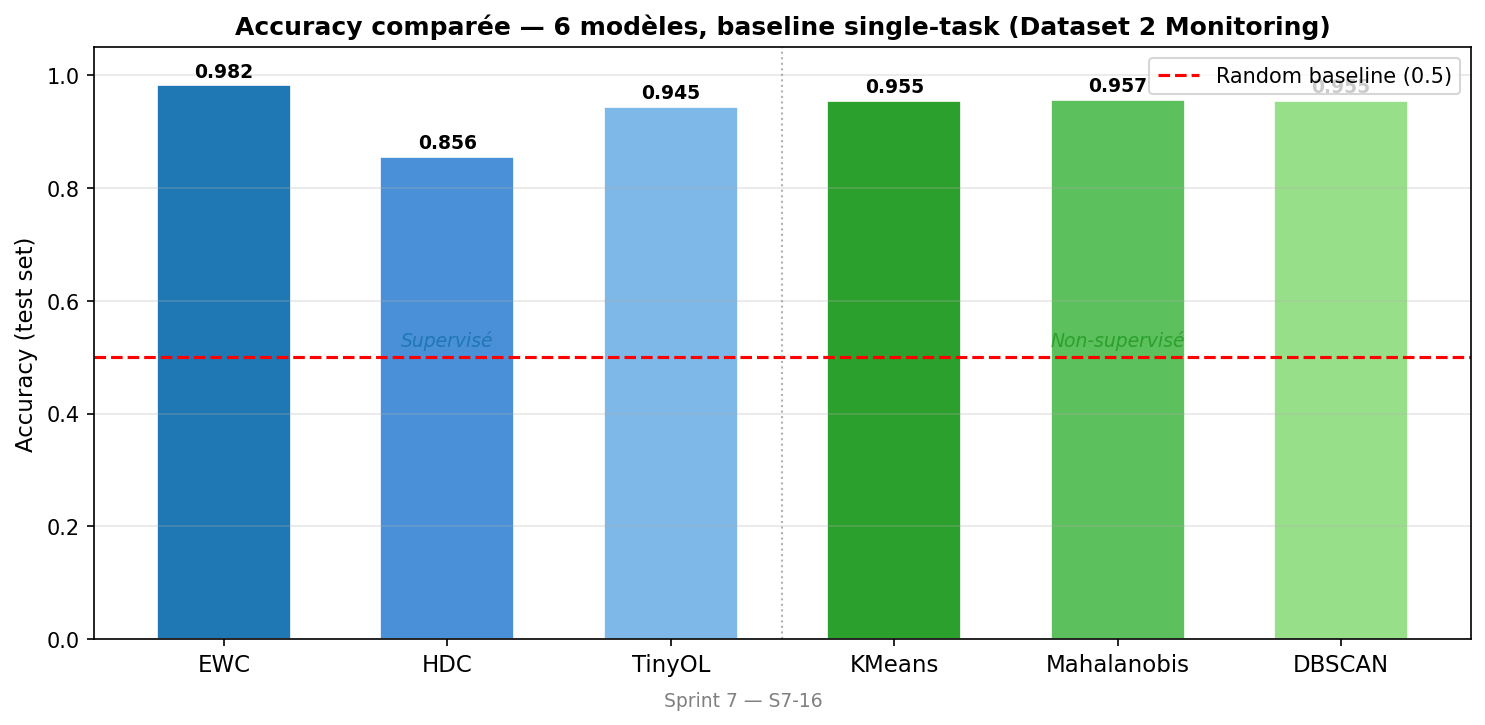

In [4]:
# Section 4 — Bar plot accuracy comparée

COLORS = {
    "EWC":         "#1f77b4",
    "HDC":         "#4a90d9",
    "TinyOL":      "#7eb8e8",
    "KMeans":      "#2ca02c",
    "Mahalanobis": "#5cc05c",
    "DBSCAN":      "#98df8a",
}

fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(MODEL_ORDER))
acc_vals = [results[name]["accuracy"] for name in MODEL_ORDER]
bar_colors = [COLORS[name] for name in MODEL_ORDER]

bars = ax.bar(x_pos, acc_vals, color=bar_colors, width=0.6,
              edgecolor="white", linewidth=0.8)

# Baseline aléatoire
ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5, label="Random baseline (0.5)")

# Valeurs annotées au-dessus de chaque barre
for bar, val in zip(bars, acc_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
    )

# Séparateur familles
ax.axvline(2.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.6)
ax.text(1.0, 0.52, "Supervisé",    ha="center", fontsize=9, color="#1f77b4", style="italic")
ax.text(4.0, 0.52, "Non-supervisé", ha="center", fontsize=9, color="#2ca02c", style="italic")

ax.set_xticks(x_pos)
ax.set_xticklabels(MODEL_ORDER, fontsize=11)
ax.set_ylabel("Accuracy (test set)", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title(
    "Accuracy comparée — 6 modèles, baseline single-task (Dataset 2 Monitoring)",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)

mock_suffix = " [MOCK]" if IS_ANY_MOCK else ""
fig.suptitle(f"Sprint 7 — S7-16{mock_suffix}", fontsize=9, color="gray", y=0.01)
fig.tight_layout()

_path = FIGURES_DIR / "comparison_bar_accuracy.png"
save_figure(fig, _path)
display(Image(str(_path)))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/monitoring/single_task/roc_curves_all_models.png


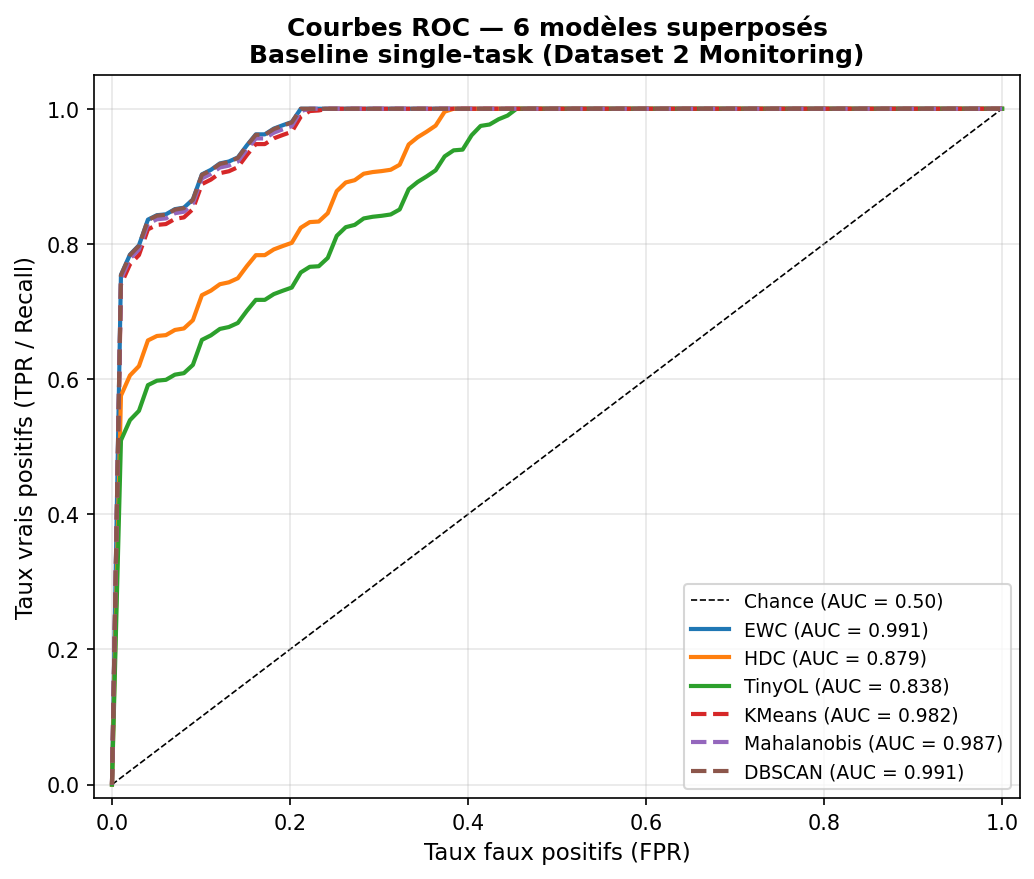

In [5]:
# Section 5 — Courbes ROC superposées (6 modèles, 1 axe)

ROC_COLORS = {
    "EWC":         "#1f77b4",
    "HDC":         "#ff7f0e",
    "TinyOL":      "#2ca02c",
    "KMeans":      "#d62728",
    "Mahalanobis": "#9467bd",
    "DBSCAN":      "#8c564b",
}
ROC_STYLES = {
    "EWC":         "-",
    "HDC":         "-",
    "TinyOL":      "-",
    "KMeans":      "--",
    "Mahalanobis": "--",
    "DBSCAN":      "--",
}

fig, ax = plt.subplots(figsize=(7, 6))

# Classifieur aléatoire
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Chance (AUC = 0.50)", zorder=0)

for name in MODEL_ORDER:
    r = results[name]
    fpr = np.array(r["fpr"])
    tpr = np.array(r["tpr"])
    auc_val = r["auc_roc"]
    ax.plot(
        fpr, tpr,
        color=ROC_COLORS[name],
        linestyle=ROC_STYLES[name],
        linewidth=2.0,
        label=f"{name} (AUC = {auc_val:.3f})",
    )

ax.set_xlabel("Taux faux positifs (FPR)", fontsize=11)
ax.set_ylabel("Taux vrais positifs (TPR / Recall)", fontsize=11)
ax.set_title(
    "Courbes ROC — 6 modèles superposés\nBaseline single-task (Dataset 2 Monitoring)",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
fig.tight_layout()

_path = FIGURES_DIR / "roc_curves_all_models.png"
save_figure(fig, _path)
display(Image(str(_path)))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/monitoring/single_task/scatter_ram_vs_accuracy.png


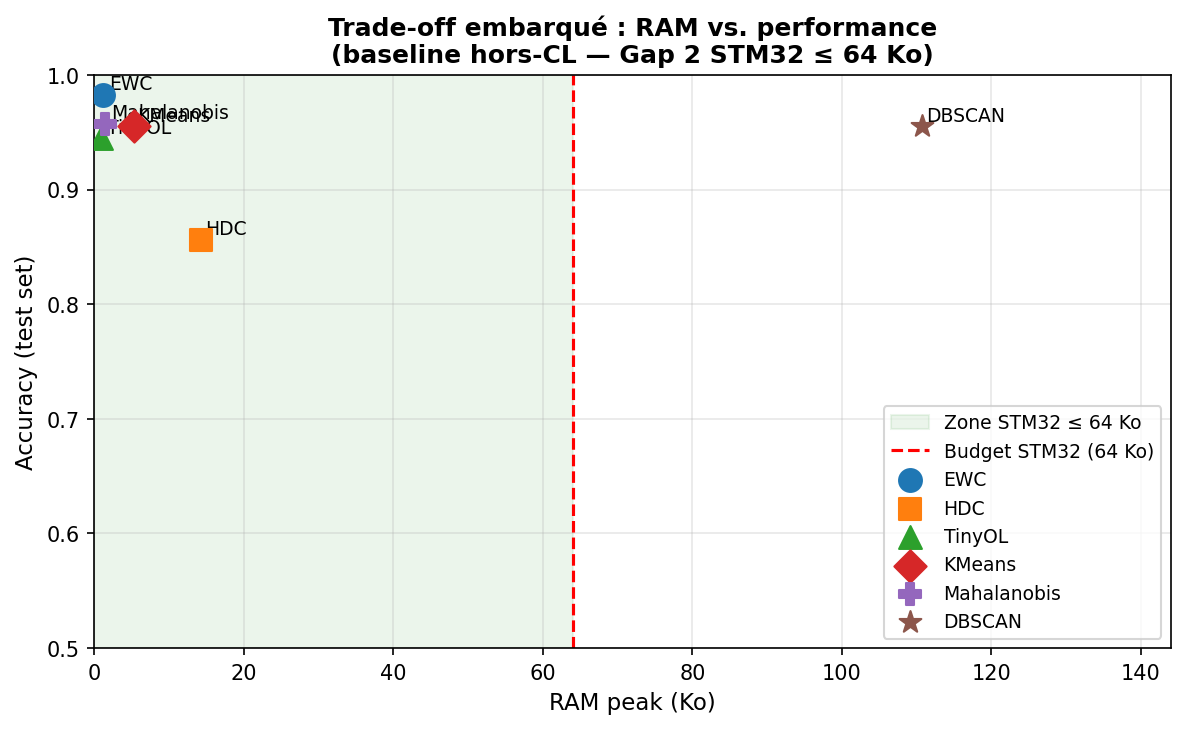

In [6]:
# Section 6 — Scatter RAM peak vs. accuracy (Gap 2 — STM32 ≤ 64 Ko)

STM32_RAM_LIMIT_KB = 64.0

SCATTER_MARKERS: dict[str, tuple[str, str]] = {
    "EWC":         ("o", "#1f77b4"),
    "HDC":         ("s", "#ff7f0e"),
    "TinyOL":      ("^", "#2ca02c"),
    "KMeans":      ("D", "#d62728"),
    "Mahalanobis": ("P", "#9467bd"),
    "DBSCAN":      ("*", "#8c564b"),
}

fig, ax = plt.subplots(figsize=(8, 5))

# Zone budget STM32
ax.axvspan(0, STM32_RAM_LIMIT_KB, alpha=0.08, color="green",
           label=f"Zone STM32 ≤ {STM32_RAM_LIMIT_KB:.0f} Ko")
ax.axvline(STM32_RAM_LIMIT_KB, color="red", linestyle="--", linewidth=1.5,
           label=f"Budget STM32 ({STM32_RAM_LIMIT_KB:.0f} Ko)")

for name in MODEL_ORDER:
    r = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    acc    = r["accuracy"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, acc, marker=marker, color=color, s=120, zorder=5, label=name)
    x_offset = 0.8 if ram_kb < 3 else 0.5
    ax.annotate(
        name,
        xy=(ram_kb, acc),
        xytext=(ram_kb + x_offset, acc + 0.005),
        fontsize=9,
    )

max_ram_kb = max(r["ram_peak_bytes"] for r in results.values()) / 1024
ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("Accuracy (test set)", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs. performance\n(baseline hors-CL — Gap 2 STM32 ≤ 64 Ko)",
    fontsize=12, fontweight="bold",
)
ax.set_xlim(0, max_ram_kb * 1.3)
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

_path = FIGURES_DIR / "scatter_ram_vs_accuracy.png"
save_figure(fig, _path)
display(Image(str(_path)))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/monitoring/single_task/scatter_flops_vs_accuracy.png


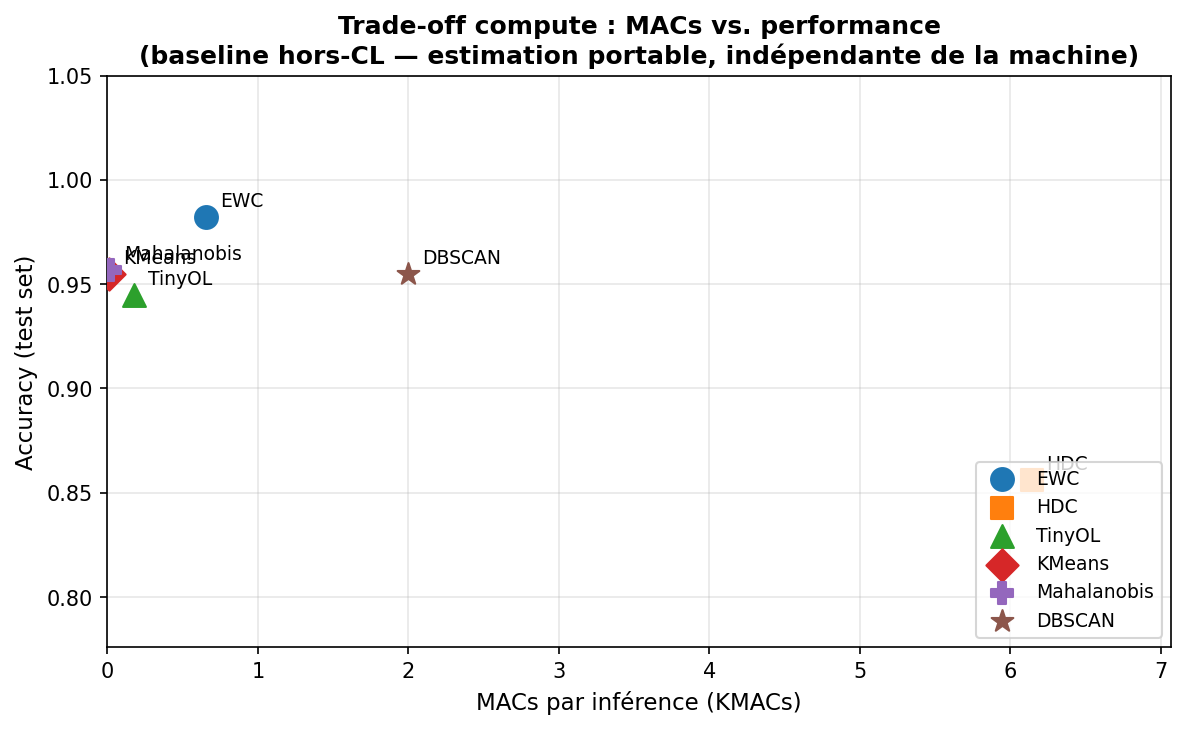

In [7]:
# Section 6b — Scatter MACs (coût de calcul) vs. accuracy
# Proxy PORTABLE : indépendant de la machine hôte, transférable au STM32N6.

fig, ax = plt.subplots(figsize=(8, 5))

macs_vals = [results[n]["n_macs"] / 1e3 for n in MODEL_ORDER]  # KMACs
macs_min = min(macs_vals)
macs_max = max(macs_vals)
USE_LOG_X = (macs_max / max(macs_min, 1)) > 100  # > 2 décades → log scale

all_accs_list = [results[n]["accuracy"] for n in MODEL_ORDER]

for name in MODEL_ORDER:
    r = results[name]
    kmacs = r["n_macs"] / 1e3
    acc   = r["accuracy"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(kmacs, acc, marker=marker, color=color, s=120, zorder=5, label=name)
    x_offset = kmacs * 0.05 if USE_LOG_X else (macs_max - macs_min) * 0.015
    ax.annotate(
        name,
        xy=(kmacs, acc),
        xytext=(kmacs + x_offset, acc + 0.005),
        fontsize=9,
    )

ax.set_xlabel("MACs par inférence (KMACs)" + (" — échelle log" if USE_LOG_X else ""), fontsize=11)
ax.set_ylabel("Accuracy (test set)", fontsize=11)
ax.set_title(
    "Trade-off compute : MACs vs. performance\n"
    "(baseline hors-CL — estimation portable, indépendante de la machine)",
    fontsize=12, fontweight="bold",
)
if USE_LOG_X:
    ax.set_xscale("log")
else:
    ax.set_xlim(0, macs_max * 1.15)
ax.set_ylim(max(0.0, min(all_accs_list) - 0.08), min(1.05, max(all_accs_list) + 0.08))
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

_path = FIGURES_DIR / "scatter_flops_vs_accuracy.png"
save_figure(fig, _path)
display(Image(str(_path)))


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/monitoring/single_task/scatter_latency_vs_accuracy.png


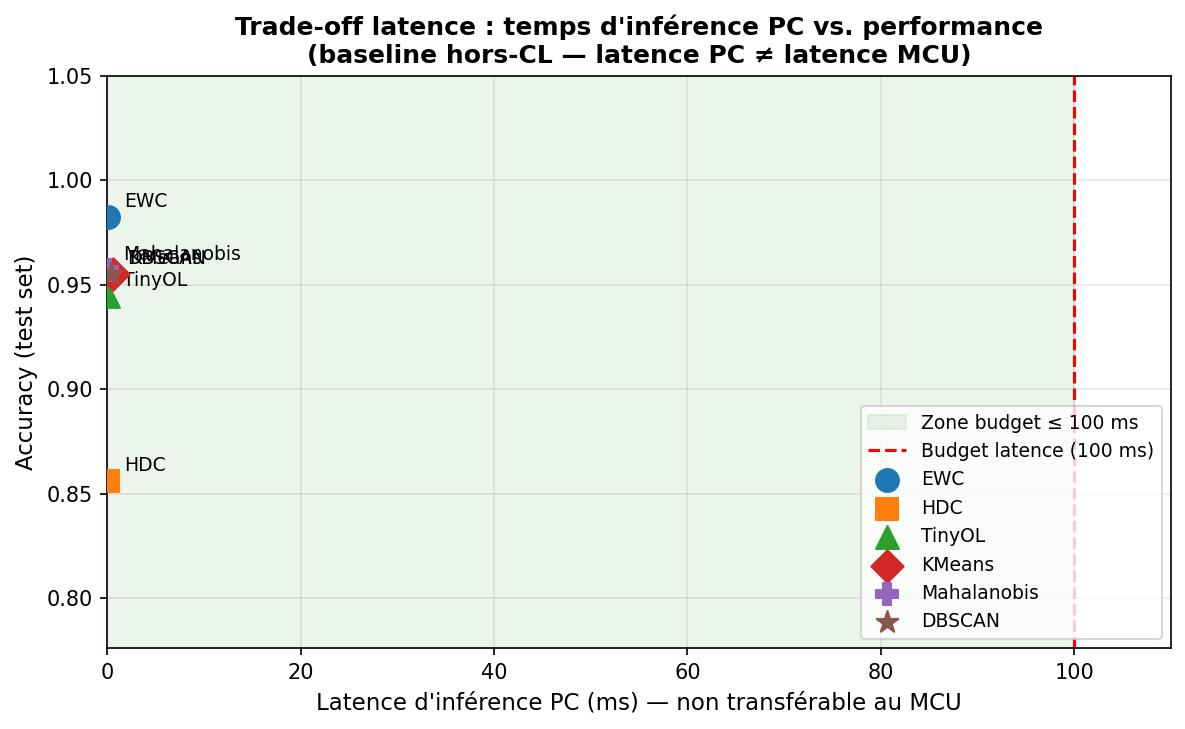

In [8]:
# Section 6c — Scatter latence d'inférence PC vs. accuracy
# ⚠ Mesure NON PORTABLE : dépend de la machine hôte (pas de NPU, fréquence ≠ MCU).
# Budget CLAUDE.md contrainte 4 : latence ≤ 100 ms par inférence + update.

LATENCY_BUDGET_MS = 100.0

fig, ax = plt.subplots(figsize=(8, 5))

lat_vals = [results[n]["inference_latency_ms"] for n in MODEL_ORDER]
lat_max = max(lat_vals)
x_max_lat = max(lat_max * 1.15, LATENCY_BUDGET_MS * 1.1)

ax.axvspan(0, LATENCY_BUDGET_MS, alpha=0.08, color="green",
           label=f"Zone budget ≤ {LATENCY_BUDGET_MS:.0f} ms")
ax.axvline(LATENCY_BUDGET_MS, color="red", linestyle="--", linewidth=1.5,
           label=f"Budget latence ({LATENCY_BUDGET_MS:.0f} ms)")

for name in MODEL_ORDER:
    r = results[name]
    lat = r["inference_latency_ms"]
    acc = r["accuracy"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(lat, acc, marker=marker, color=color, s=120, zorder=5, label=name)
    x_offset = x_max_lat * 0.015
    ax.annotate(
        name,
        xy=(lat, acc),
        xytext=(lat + x_offset, acc + 0.005),
        fontsize=9,
    )

ax.set_xlabel("Latence d'inférence PC (ms) — non transférable au MCU", fontsize=11)
ax.set_ylabel("Accuracy (test set)", fontsize=11)
ax.set_title(
    "Trade-off latence : temps d'inférence PC vs. performance\n"
    "(baseline hors-CL — latence PC ≠ latence MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_xlim(0, x_max_lat)
all_accs_list = [results[n]["accuracy"] for n in MODEL_ORDER]
ax.set_ylim(max(0.0, min(all_accs_list) - 0.08), min(1.05, max(all_accs_list) + 0.08))
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

_path = FIGURES_DIR / "scatter_latency_vs_accuracy.png"
save_figure(fig, _path)
display(Image(str(_path)))


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/monitoring/single_task/confusion_matrices_grid.png


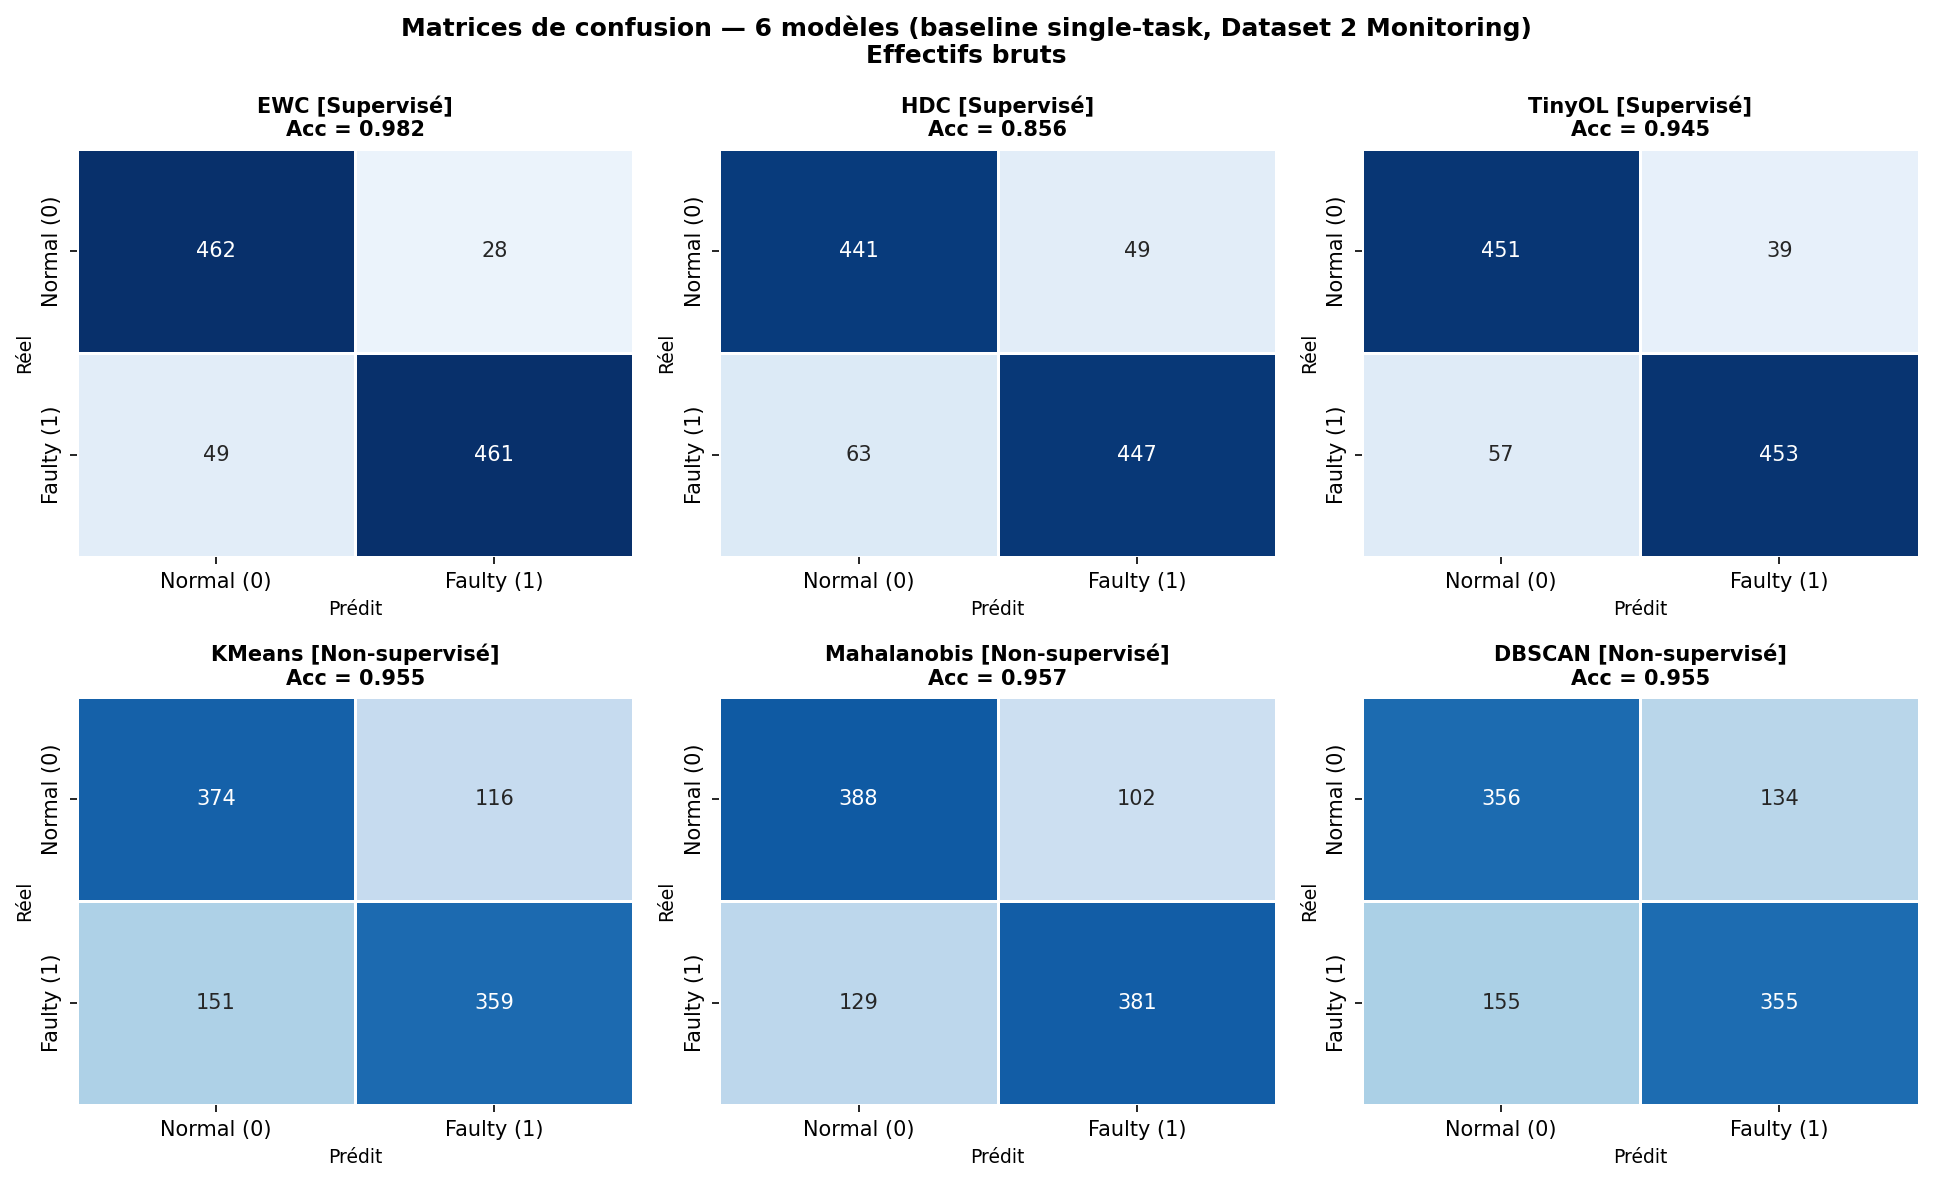

In [9]:
# Section 7 — Grille de matrices de confusion (2×3)

try:
    import seaborn as sns
    _HAS_SNS = True
except ImportError:
    _HAS_SNS = False

CLASS_NAMES = ["Normal (0)", "Faulty (1)"]
N_ROWS, N_COLS = 2, 3

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(13, 8))

# Échelle commune basée sur le max global
global_max = max(
    np.array(results[name]["confusion_matrix"]).max()
    for name in MODEL_ORDER
)

for idx, name in enumerate(MODEL_ORDER):
    row, col = divmod(idx, N_COLS)
    ax = axes[row, col]

    cm_raw = np.array(results[name]["confusion_matrix"], dtype=int)

    if _HAS_SNS:
        sns.heatmap(
            cm_raw,
            ax=ax,
            annot=True,
            fmt="d",
            cmap="Blues",
            vmin=0, vmax=global_max,
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cbar=False,
            linewidths=0.5,
            linecolor="white",
        )
    else:
        im = ax.imshow(cm_raw, cmap="Blues", vmin=0, vmax=global_max)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(CLASS_NAMES, fontsize=8)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(CLASS_NAMES, fontsize=8)
        for i in range(2):
            for j in range(2):
                ax.text(
                    j, i,
                    str(cm_raw[i, j]),
                    ha="center", va="center", fontsize=10,
                )

    family = "Supervisé" if name in SUPERVISED_MODELS else "Non-supervisé"
    acc_val = results[name]["accuracy"]
    ax.set_title(f"{name} [{family}]\nAcc = {acc_val:.3f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Prédit", fontsize=9)
    ax.set_ylabel("Réel", fontsize=9)

fig.suptitle(
    "Matrices de confusion — 6 modèles (baseline single-task, Dataset 2 Monitoring)\n"
    "Effectifs bruts",
    fontsize=12, fontweight="bold",
)
fig.tight_layout()

_path = FIGURES_DIR / "confusion_matrices_grid.png"
save_figure(fig, _path)
display(Image(str(_path)))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baseline/monitoring/single_task/confusion_matrices_grid_normalized.png


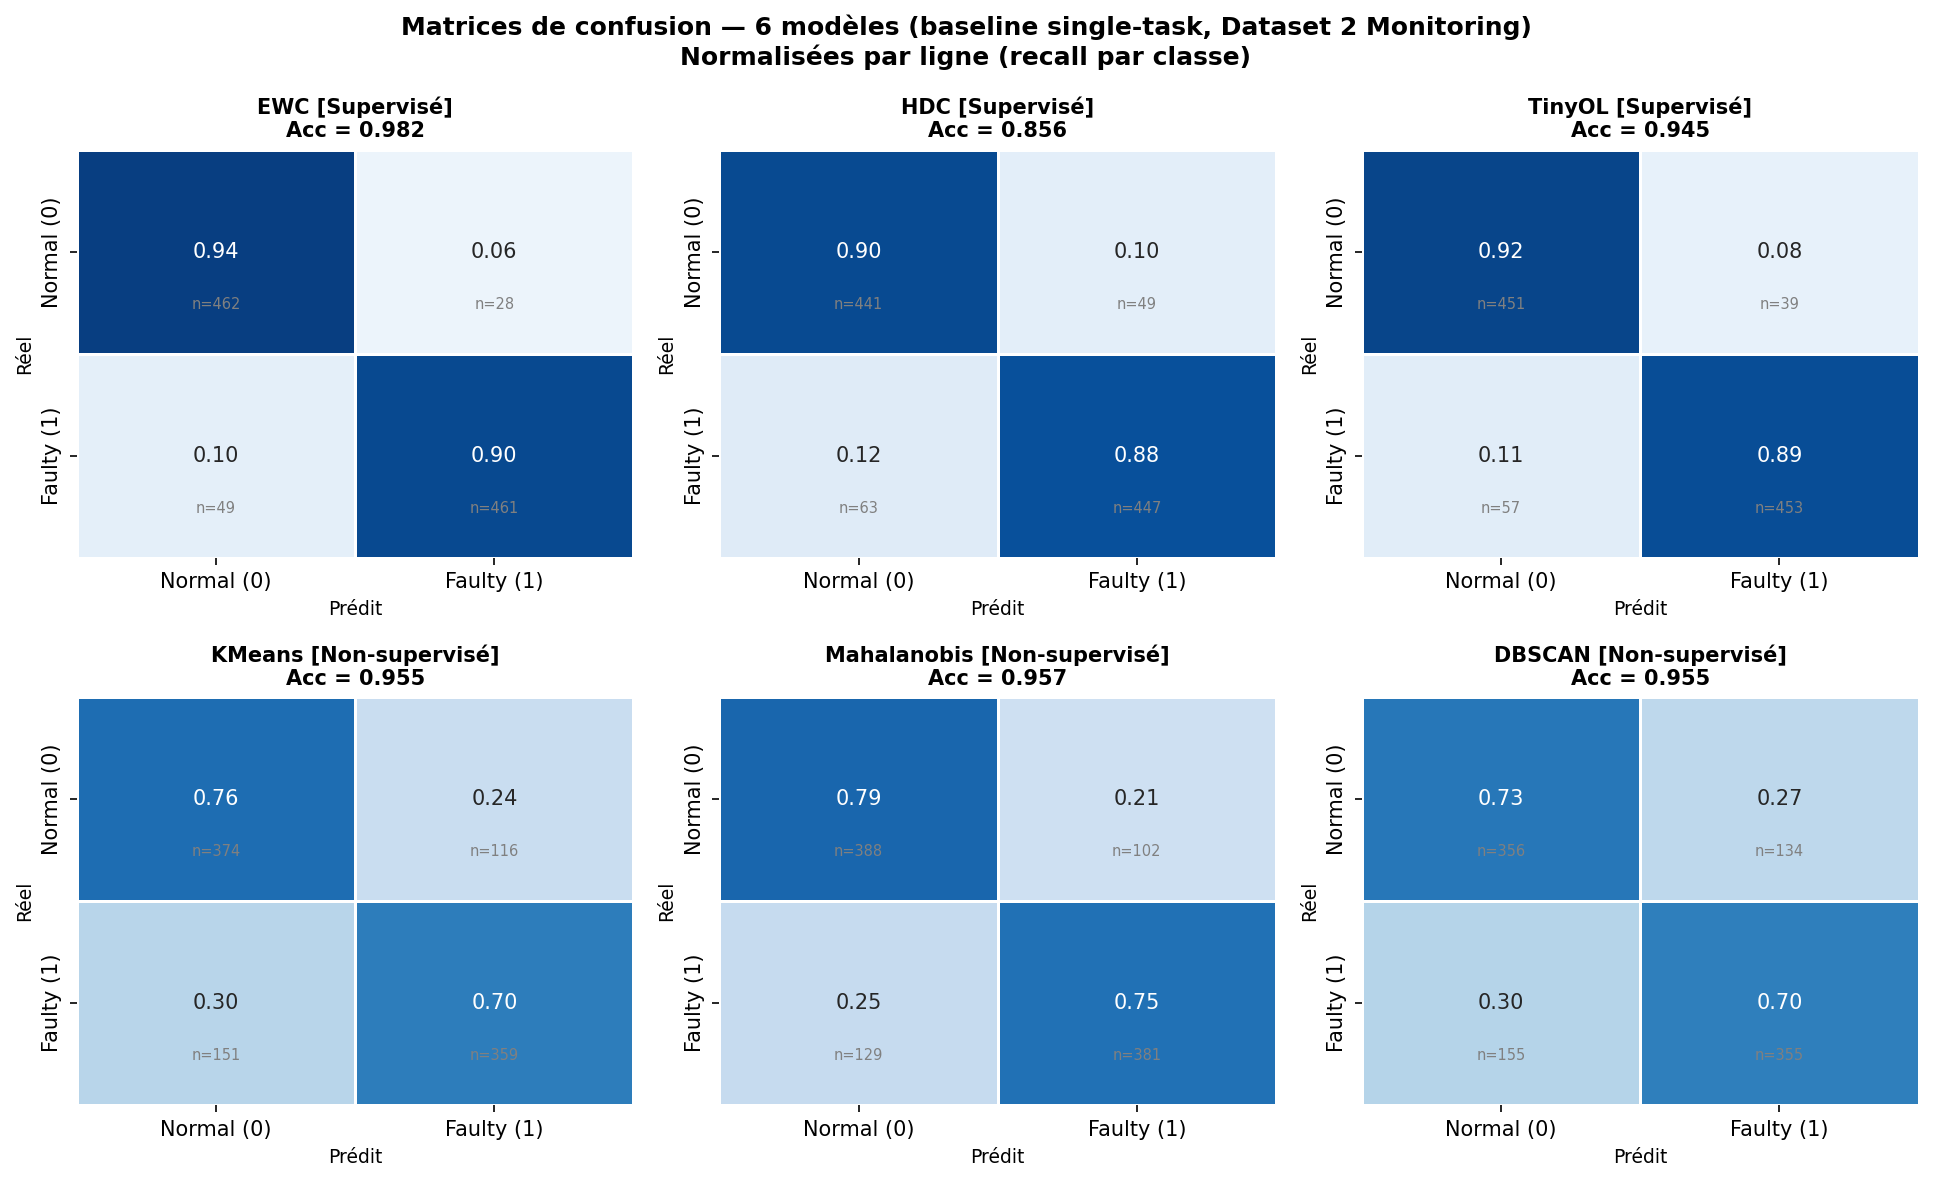

In [10]:
# Section 7 — Grille de matrices de confusion (2×3)

try:
    import seaborn as sns
    _HAS_SNS = True
except ImportError:
    _HAS_SNS = False

CLASS_NAMES = ["Normal (0)", "Faulty (1)"]
N_ROWS, N_COLS = 2, 3

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(13, 8))

for idx, name in enumerate(MODEL_ORDER):
    row, col = divmod(idx, N_COLS)
    ax = axes[row, col]

    cm_raw = np.array(results[name]["confusion_matrix"], dtype=float)

    # Normalisation par ligne (recall par classe)
    row_sums = cm_raw.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    cm_norm = cm_raw / row_sums

    if _HAS_SNS:
        sns.heatmap(
            cm_norm,
            ax=ax,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            vmin=0, vmax=1,
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cbar=False,
            linewidths=0.5,
            linecolor="white",
        )
        # Overlay effectifs bruts
        for i in range(2):
            for j in range(2):
                ax.text(
                    j + 0.5, i + 0.78,
                    f"n={int(cm_raw[i, j])}",
                    ha="center", fontsize=7, color="gray",
                )
    else:
        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(CLASS_NAMES, fontsize=8)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(CLASS_NAMES, fontsize=8)
        for i in range(2):
            for j in range(2):
                ax.text(
                    j, i,
                    f"{cm_norm[i, j]:.2f}\n(n={int(cm_raw[i, j])})",
                    ha="center", va="center", fontsize=8,
                )

    family = "Supervisé" if name in SUPERVISED_MODELS else "Non-supervisé"
    acc_val = results[name]["accuracy"]
    ax.set_title(f"{name} [{family}]\nAcc = {acc_val:.3f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Prédit", fontsize=9)
    ax.set_ylabel("Réel", fontsize=9)

fig.suptitle(
    "Matrices de confusion — 6 modèles (baseline single-task, Dataset 2 Monitoring)\n"
    "Normalisées par ligne (recall par classe)",
    fontsize=12, fontweight="bold",
)
fig.tight_layout()

_path = FIGURES_DIR / "confusion_matrices_grid_normalized.png"
save_figure(fig, _path)
display(Image(str(_path)))

In [11]:
# Section 8 — Discussion

best_model = max(MODEL_ORDER, key=lambda n: results[n]["accuracy"])
best_sup   = max(SUPERVISED_MODELS,   key=lambda n: results[n]["accuracy"])
best_unsup = max(UNSUPERVISED_MODELS, key=lambda n: results[n]["accuracy"])
gap_sup_unsup   = results[best_sup]["accuracy"] - results[best_unsup]["accuracy"]
models_in_budget = [n for n in MODEL_ORDER if results[n]["ram_peak_bytes"] <= 65_536]

best_compute = min(MODEL_ORDER, key=lambda n: results[n]["n_macs"])
worst_compute = max(MODEL_ORDER, key=lambda n: results[n]["n_macs"])
best_compute_macs  = results[best_compute]["n_macs"]
worst_compute_macs = results[worst_compute]["n_macs"]
best_lat   = min(MODEL_ORDER, key=lambda n: results[n]["inference_latency_ms"])
worst_lat  = max(MODEL_ORDER, key=lambda n: results[n]["inference_latency_ms"])

mock_note = "\n> ⚠️ *Ces résultats sont basés sur des données mock — interpréter avec précaution.*" if IS_ANY_MOCK else ""

discussion = f"""
## Discussion — Baseline Single-Task (Dataset 2 Monitoring){mock_note}

### 1. Performance sans CL
Le modèle le plus performant sans contrainte CL est **{best_model}**
(accuracy = {results[best_model]['accuracy']:.3f}, AUC-ROC = {results[best_model]['auc_roc']:.3f}).
C'est la **borne supérieure** pour toute approche CL sur ce dataset.

### 2. Écart supervisé / non-supervisé
Le meilleur modèle supervisé ({best_sup}, acc = {results[best_sup]['accuracy']:.3f})
est à {'+' if gap_sup_unsup >= 0 else ''}{gap_sup_unsup:.3f} points du meilleur
modèle non-supervisé ({best_unsup}, acc = {results[best_unsup]['accuracy']:.3f}).

### 3. Contrainte RAM (Gap 2)
Modèles dans le budget STM32 ≤ 64 Ko : {', '.join(models_in_budget)}.
Les 6 modèles tiennent largement sous le budget (sauf DBSCAN selon configuration).

### 4. Coût de calcul (MACs) — proxy portable
Estimation analytique du coût d'inférence, indépendante de la machine hôte
(cf. `src/evaluation/compute_cost.py`). Le plus économe est **{best_compute}**
({best_compute_macs:,} MACs), le plus coûteux est **{worst_compute}**
({worst_compute_macs:,} MACs, soit ×{worst_compute_macs / max(best_compute_macs, 1):.0f}).
Ces chiffres sont le seul proxy *portable* au STM32N6 : le NPU sur Cortex-M55
offre environ 300 GOPS, donc même le modèle le plus coûteux reste largement
sous la contrainte latence 100 ms *en théorie* (le goulot réel viendra de la
backprop en SW et des transferts mémoire, pas du forward).

### 5. Latence PC — ⚠ mesure non portable
La latence mesurée ici ({results[best_lat]['inference_latency_ms']:.3f} ms pour
{best_lat}, jusqu'à {results[worst_lat]['inference_latency_ms']:.3f} ms pour
{worst_lat}) est une mesure PC : elle **ne se transpose pas au MCU**
(pas de NPU, fréquence Cortex-M55 ≈ 800 MHz vs. CPU PC plusieurs GHz, pipeline
différent). Elle est utile pour comparer les modèles entre eux sur la même
machine, mais pour la validation du budget 100 ms → référer au sprint 10
(port STM32N6) + extrapolation à partir des MACs.

### 6. Pont vers les notebooks CL (S7-01 à S7-14)
Ces scores constituent la référence absolue. Les notebooks de Sprint 7 montrent
ce qui se passe quand on introduit le découpage en tâches séquentielles
(domain-incremental par type d'équipement ou par localisation). On s'attend à ce
que l'accuracy CL soit inférieure à ces baselines, quantifiant le **coût du CL**.
"""

display(Markdown(discussion))



## Discussion — Baseline Single-Task (Dataset 2 Monitoring)

### 1. Performance sans CL
Le modèle le plus performant sans contrainte CL est **EWC**
(accuracy = 0.982, AUC-ROC = 0.991).
C'est la **borne supérieure** pour toute approche CL sur ce dataset.

### 2. Écart supervisé / non-supervisé
Le meilleur modèle supervisé (EWC, acc = 0.982)
est à +0.025 points du meilleur
modèle non-supervisé (Mahalanobis, acc = 0.957).

### 3. Contrainte RAM (Gap 2)
Modèles dans le budget STM32 ≤ 64 Ko : EWC, HDC, TinyOL, KMeans, Mahalanobis.
Les 6 modèles tiennent largement sous le budget (sauf DBSCAN selon configuration).

### 4. Coût de calcul (MACs) — proxy portable
Estimation analytique du coût d'inférence, indépendante de la machine hôte
(cf. `src/evaluation/compute_cost.py`). Le plus économe est **KMeans**
(12 MACs), le plus coûteux est **HDC**
(6,144 MACs, soit ×512).
Ces chiffres sont le seul proxy *portable* au STM32N6 : le NPU sur Cortex-M55
offre environ 300 GOPS, donc même le modèle le plus coûteux reste largement
sous la contrainte latence 100 ms *en théorie* (le goulot réel viendra de la
backprop en SW et des transferts mémoire, pas du forward).

### 5. Latence PC — ⚠ mesure non portable
La latence mesurée ici (0.007 ms pour
Mahalanobis, jusqu'à 0.569 ms pour
KMeans) est une mesure PC : elle **ne se transpose pas au MCU**
(pas de NPU, fréquence Cortex-M55 ≈ 800 MHz vs. CPU PC plusieurs GHz, pipeline
différent). Elle est utile pour comparer les modèles entre eux sur la même
machine, mais pour la validation du budget 100 ms → référer au sprint 10
(port STM32N6) + extrapolation à partir des MACs.

### 6. Pont vers les notebooks CL (S7-01 à S7-14)
Ces scores constituent la référence absolue. Les notebooks de Sprint 7 montrent
ce qui se passe quand on introduit le découpage en tâches séquentielles
(domain-incremental par type d'équipement ou par localisation). On s'attend à ce
que l'accuracy CL soit inférieure à ces baselines, quantifiant le **coût du CL**.
